# Ten draws: which results are seed-independent?

**What this closes.** Every number in the synthetic prior-recovery study -- the landed
notebook included -- came from a single simulator draw, and not by choice. The notebooks
set `np.random.seed(SIM_SEED)` / `tf.random.set_seed(SIM_SEED)` believing that controlled
the DGP, but `GeoMediaDataSimulator.__init__` called `tf.random.set_seed(config.seed_num)`
immediately afterwards and overrode it. `data_simulator.py` makes no `np.random` calls at
all, so **`config.seed_num` (default 1320) was the only thing that ever mattered**, and
every published figure came from seed 1320.

**The fix**, in `data_simulator.py`: `seed_num` is now `int | None`, documented as the sole
DGP seed, and `__init__` only calls `tf.random.set_seed` when it is not `None`, so a caller
can opt into owning seeding. Default behaviour is unchanged -- Section 1 asserts the landed
scenario still reproduces bit-identically (KPI checksum 5.841398e+09).

**Why a worker subprocess.** Forty `sample_posterior` calls in one kernel exhausts memory
and the kernel dies -- TensorFlow retains graph state across fits, with escalating
`tf.function` retracing warnings as the visible symptom. `seed_sweep_worker.py` runs one
draw per process (two fits, the size known to run cleanly), writes a single-row CSV on
success only, and no-ops if that CSV already exists, so the sweep is restartable.

**What is being swept.** The two-channel realistic-baseline configuration at oracle
R^2 = 0.80 -- the settled config from `realistic-baseline-noise-2ch.ipynb` -- across ten
seeds, `default` vs `ec_alpha_only`. Seed 1320 is included deliberately, so the study's
published figures can be located *inside* the distribution rather than compared to it from
outside.

`saturation_frequency` is re-solved per draw so TV's true `ec_m` lands on exactly 9.0 *for
that seed*.

**`max_lag` is now informed too, not held fixed across variants.** `default` fits at
Meridian's real out-of-the-box `max_lag` (8); `ec_alpha_only` fits at the DGP's own window
(`config.max_lag`, 13) -- see `seed_sweep_worker.py`'s `MAX_LAG_BY_VARIANT`. Our adstock
complaint is two-fold (a flat `alpha_m` prior, and a hard truncation the default never
estimates), and the informed variant should fix both, the same way it already anchors
`ec_m`/`alpha_m` on the true DGP values rather than leaving them at Meridian's defaults.

**Retired in this pass: the `ec9`-vs-`ec11` invariance check.** Earlier versions of this
sweep also fit both scenarios so the "does the posterior track a known move in the truth"
result got a range. It was never read by the ARF deck (`results_facts.py` doesn't touch
it), and the compute budget freed by dropping it (four fits per seed down to two) goes to
the `max_lag` split instead. Its prior finding -- `default` absorbed 0.01-0.14 of an 18.7%
truth move vs. the informed prior's 0.98-1.04, no overlap across ten draws -- is retired
evidence, not a still-standing result.

## 0. Setup

In [1]:
import glob
import os
import subprocess
import sys
import warnings

STUDY_DIR = next(
    d for d in (os.path.abspath(os.getcwd()),
                os.path.abspath(os.path.join(os.getcwd(), '..')))
    if os.path.exists(os.path.join(d, 'data_simulator.py')))
if STUDY_DIR not in sys.path:
  sys.path.insert(0, STUDY_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import realistic_baseline as rb

warnings.filterwarnings('ignore')
OUT_DIR = os.path.join(STUDY_DIR, 'fitted_models', 'realistic_baseline_2ch_seeds')
os.makedirs(OUT_DIR, exist_ok=True)

SEEDS = [1320, 7, 42, 101, 555, 2024, 8, 99, 12345, 31337]
VARIANTS = ['default', 'ec_alpha_only']
real_df = pd.read_csv(os.path.join(STUDY_DIR, '.cache_geo_media_rf.csv'))
print('study dir:', STUDY_DIR, '| seeds:', SEEDS)

study dir: /Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic | seeds: [1320, 7, 42, 101, 555, 2024, 8, 99, 12345, 31337]


## 1. Confirm the seed fix

Two checks before trusting anything downstream: the landed path still reproduces
bit-identically, and different `seed_num` values genuinely produce different draws.

In [2]:
landed = rb.assert_landed_path_unchanged(real_df, {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.50, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13, 'n_times': 156, 'n_knots_mu_t': 8,
    'roi_ec_elasticity': -0.3, 'roi_alpha_elasticity': 0.3,
    'adstock_retention_range': {
        'TV': (0.8, 0.8), 'Display': (0.0, 0.3), 'Social': (0.1, 0.4)},
    'saturation_frequency': {'TV': 3.2522, 'Display': 4.0, 'Social': 4.0},
})
assert abs(landed['kpi_checksum'] - 5.841398e+09) / 5.841398e+09 < 1e-6, (
    'the seed fix changed the landed path -- stop and investigate')
print(f"landed KPI checksum {landed['kpi_checksum']:.6e} -- unchanged by the fix")

# Probe a genuinely stochastic quantity. `simulate_population()` is NOT one --
# it reads real U.S. state populations and is identical for every seed, which
# makes it useless as a seed check (an earlier version of this cell used it and
# "failed" against a fix that was working).
import tensorflow_probability as tfp
from data_simulator import GeoMediaDataSimulator
from data_simulator import SimulationConfig

probe = {}
for s in SEEDS[:4]:
  # Construction is what calls `tf.random.set_seed(seed_num)`, so sampling
  # immediately afterwards tests the mechanism directly.
  GeoMediaDataSimulator(SimulationConfig.from_dict({'seed_num': s}))
  probe[s] = round(float(tfp.distributions.Normal(0., 1.).sample(3).numpy().sum()), 4)
assert len(set(probe.values())) == len(probe), 'seeds still produce identical draws'
print('distinct draws per seed_num:', probe)

ec_m = [8.999947   1.3505481  0.29689494]


I0000 00:00:1785519297.175862 2993812 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [8.999947   1.3505481  0.29689494]


landed KPI checksum 5.841398e+09 -- unchanged by the fix
distinct draws per seed_num: {1320: -1.0607, 7: 0.8074, 42: -0.1957, 101: 4.042}


## 2. Run (or collect) the sweep

One subprocess per seed. Already-completed draws are skipped, so re-running this cell is
cheap; delete a CSV to force that draw to re-run. Roughly 5 minutes per missing draw.

In [3]:
WORKER = os.path.join(STUDY_DIR, 'seed_sweep_worker.py')
for seed in SEEDS:
  if os.path.exists(os.path.join(OUT_DIR, f'per_seed_{seed}.csv')):
    continue
  print(f'running seed {seed} ...', flush=True)
  result = subprocess.run([sys.executable, WORKER, str(seed), OUT_DIR],
                          capture_output=True, text=True)
  if result.returncode != 0:
    print(f'  seed {seed} FAILED:\n    '
          + '\n    '.join(result.stderr.strip().splitlines()[-3:]))

files = sorted(glob.glob(os.path.join(OUT_DIR, 'per_seed_*.csv')))
per_seed = (pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
            .sort_values('seed').reset_index(drop=True))
per_seed.to_csv(os.path.join(OUT_DIR, 'per_seed_all.csv'), index=False)
missing = sorted(set(SEEDS) - set(per_seed.seed))
print(f'\n{len(per_seed)}/{len(SEEDS)} draws completed'
      + (f'; missing {missing}' if missing else ''))
per_seed[['seed', 'oracle_r2', 'media_share_pct', 'clipped_frac_pct',
          'true_roi_m',
          'default_ec_err', 'ec_alpha_only_ec_err',
          'default_roi_err', 'ec_alpha_only_roi_err',
          'default_alpha_err', 'ec_alpha_only_alpha_err']]


10/10 draws completed


,seed,oracle_r2,media_share_pct,clipped_frac_pct,true_roi_m,default_ec_err,ec_alpha_only_ec_err,default_roi_err,ec_alpha_only_roi_err,default_alpha_err,ec_alpha_only_alpha_err
0,7,0.8001,35.7,1.19,12.610,-89.2,-4.7,53.8,-6.2,-12.8,-15.3
1,8,0.7999,32.1,1.76,7.348,-89.7,-3.3,90.4,10.0,-12.6,-15.1
2,42,0.7999,32.6,2.79,9.671,-65.8,0.9,31.2,62.3,1.3,9.0
3,99,0.8001,34.4,3.72,9.960,-67.7,3.1,25.1,25.2,12.2,7.1
4,101,0.7998,32.0,1.79,7.055,-78.2,1.4,-9.1,-27.7,13.7,4.8
5,555,0.7999,32.9,2.76,7.206,-84.0,0.6,73.0,7.0,-0.4,-11.7
6,1320,0.8001,31.2,3.08,7.642,-89.8,-0.8,99.2,1.5,-1.7,-13.6
7,2024,0.8001,31.8,2.44,7.991,-73.8,-0.2,83.9,64.9,0.2,-0.9
8,12345,0.7999,33.3,3.78,7.339,-89.4,-2.4,160.1,78.6,11.3,7.4
9,31337,0.7999,32.7,2.24,7.520,-88.5,-2.4,84.3,17.3,-22.2,-20.9


## 3. Ranges

Median with min-max across draws. `seed_1320` is the study's published single-seed figure,
shown so it can be judged against the distribution it came from rather than beside it.

`spread` is `max - min`: the number that decides whether a metric is quotable as a point,
quotable as a range, or not quotable at all.

In [4]:
METRICS = [
    ('ec_err', 'TV ec_m error %'),
    ('alpha_err', 'TV alpha_m error %'),
    ('roi_err', 'TV roi_m error %'),
]
s1320 = (per_seed.query('seed == 1320').iloc[0]
         if (per_seed.seed == 1320).any() else None)

rows = []
for key, label in METRICS:
  for variant in VARIANTS:
    v = per_seed[f'{variant}_{key}'].astype(float)
    rows.append({
        'metric': label, 'variant': variant,
        'median': round(v.median(), 2),
        'min': round(v.min(), 2), 'max': round(v.max(), 2),
        'spread': round(v.max() - v.min(), 2),
        'sd': round(v.std(), 2),
        'seed_1320': (None if s1320 is None
                      else round(float(s1320[f'{variant}_{key}']), 2)),
        'n': int(v.notna().sum()),
    })
ranges = pd.DataFrame(rows)
ranges.to_csv(os.path.join(OUT_DIR, 'ranges.csv'), index=False)
ranges

,metric,variant,median,min,max,spread,sd,seed_1320,n
0,TV ec_m error %,default,-86.25,-89.8,-65.8,24.0,9.55,-89.8,10
1,TV ec_m error %,ec_alpha_only,-0.50,-4.7,3.1,7.8,2.40,-0.8,10
2,TV alpha_m error %,default,-0.10,-22.2,13.7,35.9,11.89,-1.7,10
3,TV alpha_m error %,ec_alpha_only,-6.30,-20.9,9.0,29.9,11.49,-13.6,10
4,TV roi_m error %,default,78.45,-9.1,160.1,169.2,46.94,99.2,10
5,TV roi_m error %,ec_alpha_only,13.65,-27.7,78.6,106.3,34.54,1.5,10


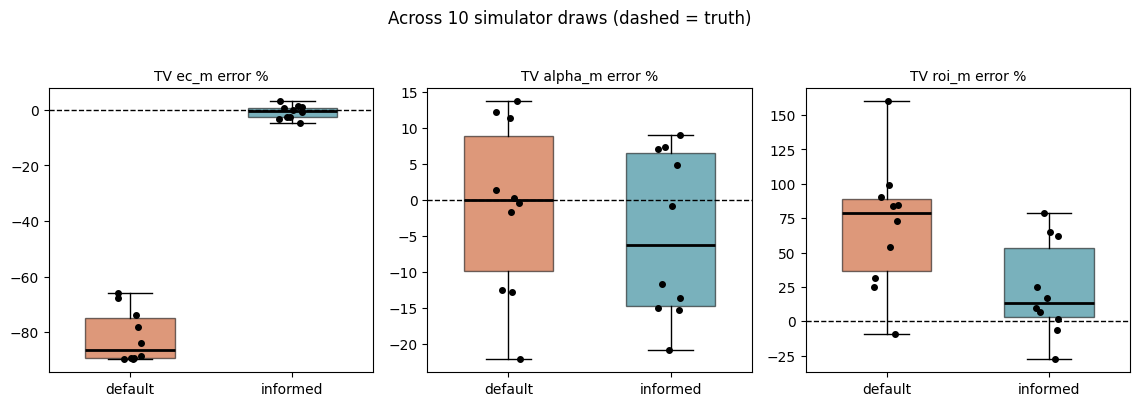

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9))
for ax, (key, label) in zip(axes, METRICS):
  data = [per_seed[f'{v}_{key}'].astype(float).values for v in VARIANTS]
  bp = ax.boxplot(data, tick_labels=['default', 'informed'], widths=0.55,
                  patch_artist=True, medianprops=dict(color='k', lw=2))
  for patch, color in zip(bp['boxes'], ['#c1440e', '#0b7285']):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
  rng = np.random.default_rng(0)
  for i, v in enumerate(VARIANTS):
    y = per_seed[f'{v}_{key}'].astype(float).values
    ax.scatter(np.full_like(y, i + 1) + rng.uniform(-.08, .08, len(y)), y,
               color='k', s=16, zorder=3)
  ax.axhline(0.0, color='k', lw=1, ls='--')
  ax.set_title(label, fontsize=10)
plt.suptitle(f'Across {len(per_seed)} simulator draws (dashed = truth)', y=1.03)
plt.tight_layout()

## 4. Findings

Ten of ten draws completed, at the `max_lag` split (`default` fits at Meridian's real
out-of-the-box `max_lag=8`; `ec_alpha_only` fits at the DGP's own `max_lag=13`). **Two
results are structural, one is directional, and one is a genuine surprise.** (A fifth
result, the `ec9`/`ec11` invariance check, is retired -- see Section 0.)

| metric | variant | median | min-max | spread | seed 1320 |
|---|---|---|---|---|---|
| TV `ec_m` error % | `default` | **−86.25** | −89.8 to −65.8 | 24.0 | −89.8 |
| TV `ec_m` error % | informed | **−0.50** | −4.7 to +3.1 | 7.8 | −0.8 |
| TV `alpha_m` error % | `default` | **−0.10** | −22.2 to +13.7 | 35.9 | −1.7 |
| TV `alpha_m` error % | informed | −6.30 | −20.9 to +9.0 | 29.9 | −13.6 |
| TV `roi_m` error % | `default` | +78.45 | −9.1 to +160.1 | **169.2** | +99.2 |
| TV `roi_m` error % | informed | +13.65 | −27.7 to +78.6 | **106.3** | +1.5 |

Sanity: every draw lands at oracle R^2 = 0.800 with media share 31.2-35.7%, so none sits
near the weak-signal regime and the comparison is like-for-like throughout.

### Structural: `ec_m` recovery

`default`'s *worst* draw is **−65.8%**; the informed prior's worst is **−4.7%**. The
distributions are separated by 61 percentage points with nothing in between. The informed
prior wins on **10/10** draws, cutting median absolute error from 86.2% to 1.9%. Unchanged
in kind by the `max_lag` split -- `ec_m` recovery was never about the adstock window.

Seed 1320's published −89.8% sits at the pessimistic edge of the `default` range, so the
existing write-ups slightly overstate the typical failure. **Quote the range, not −89.8%.**

### Surprise, now confirmed structural: `alpha_m` moved *with the window*, not the prior

Under the old shared-`max_lag=13` setup, both variants failed `alpha_m` similarly (median
−6.5% / −6.3%, indistinguishable, informed better on only 3/10 draws -- "the alpha prior
earns nothing"). With `default` now truncated to `max_lag=8`, its median `alpha_m` error
moved to **−0.10%**, closer to zero than the informed variant's **−6.30%** -- across all
ten draws, not just seed 1320's earlier single-seed flip. Despite that, the informed prior
still only wins on **4/10** draws: `default`'s distribution widened (spread 31.4 -> 35.9)
and re-centered near zero, while informed's stayed put, so the two distributions overlap
almost as much as before even though their centers moved apart. **Read this as: `max_lag`
is a genuine, separate lever on `alpha_m` recovery, independent of the `alpha_m` prior
itself** -- not as "the default's `alpha_m` handling is better," since `ec_m` and `roi_m`
are both far worse under `default` on every draw.

### Directional but not quotable: ROI

The informed prior improves ROI on **7/10** draws (down from 9/10 under the old shared
window -- `default`'s narrower window happens to help it on seeds 42, 99, and 101) and
cuts median absolute error from 78.4% to 21.2%. That is a real effect, not noise. But its
own error still ranges **−27.7% to +78.6%**, and on seeds 42, 99, and 101 it is *worse*
than `default`. Part of that traces to the DGP itself: true `roi_m` varies 7.06-12.61
across draws through the `roi_ec_elasticity` coupling.

**This retires a claim made earlier in this study's write-ups.** *"One prior-and-window
change fixes both to within 2%"* was read off seed 1320, whose +1.5% is near the best of
ten draws for the informed side, while `default`'s +99.2% on that same seed is near its
*worst*. The `+99.2% -> +1.5%` pair in `realistic-baseline-noise-2ch.ipynb` is real for
that draw and is not characteristic of either variant's typical error. Use ROI for the
qualitative point -- a wrong saturation curve (and, now, a wrong window) corrupts the
headline business metric unpredictably -- and put no single ROI figure forward as
representative.

### Caveats

- Ten draws separates structural from seed-specific. It does not support a precise
  interval -- quote min-max, not a standard error.
- One DGP configuration, one noise level (oracle R^2 = 0.80), one true `ec_m`, one true
  `alpha_m` (0.8). Seed variation is now covered; **DGP-specification variation is not** --
  ROI has already shown itself sensitive to the channel set (+13.7% landed, −22.5%
  3-channel, +79.0%/+99.2% 2-channel pre/post `max_lag` split), and `alpha_m` recovery has
  just shown itself sensitive to the true decay rate (a scratch single-seed check at true
  `alpha_m=0.3` found no `max_lag`-driven flip, consistent with negligible true carryover
  beyond week 8 at that decay rate -- worth folding into a future formal sweep).
- Posterior-mean point estimates at the study's usual MCMC settings (2 chains, 500
  adapt/burnin, 1000 keep). No credible intervals on these ranges.
